# Galactic-binary parameter inference with `jexplore`

Bayesian inference of the parameters of a **single galactic binary (GB)** from a
one-month LISA A/E/T frequency-domain datastream, using the affine-invariant
ensemble sampler [`jexplore`](https://pypi.org/project/jexplore/).

The datastream (clean signal + instrumental noise) and the noise PSD are produced
**entirely by the helpers in [`canna/lisa.py`](canna/lisa.py)** — `clean_signal`,
`sample_noise` and `noise_psd` — the same code that feeds the diffusion model in
[scripts/train.py](scripts/train.py). This notebook is the MCMC cross-check of that pipeline.

We sample the four parameters **`θ = [f₀, ḟ, A, ψ]`**, holding the sky position and
orientation `(ra, dec, ι, φ₀)` fixed at their injected values, and recover **all
four constrained**.

Inspired by [glitch_and_gb.ipynb](glitch_and_gb.ipynb) but with the glitch sector
removed — here there is *only* a galactic binary.

## Choosing a constrainable injection

`ḟ` is only measurable if the frequency chirp builds up enough phase over the
observation: its precision scales as `σ_ḟ ∝ 1 / (SNR · T_obs²)`. With the
`lisa.prior_inverse_cdf` training scale (`ḟ ≤ 4×10⁻¹⁸`) over a short baseline the
chirp is unresolvable and the `ḟ` marginal collapses onto the prior.

So, exactly as `glitch_and_gb.ipynb` does (it uses a *heavy-chirp* `ḟ = 10⁻¹⁷` over a
**1-year** baseline and **raises the `ḟ`/`A` prior caps** above the training prior),
we pick a heavy chirp here too. We run at **1-month** resolution (this GPU only has
~2 GB free; the year-long grid OOMs), and since `σ_ḟ ∝ 1/T_obs²` a month needs a
correspondingly heavier chirp `ḟ = 10⁻¹⁶` to reach the same resolvability — then all
four parameters are data-constrained. `f₀`, `A`, `ψ` are constrained at the
`lisa.prior_inverse_cdf` scale already.

## Likelihood normalisation

`lisa.sample_noise` colours the frequency-domain noise to the **physical one-sided
PSD** `S(f) = lisa.noise_psd(freqs)[channel]`: each rfft bin has
`E[|n_f|²] = (N / 2·dt)·S(f)` with `N = T_obs/dt`, so the estimator
`(2·dt/N)·|rfft(n)|²` is an unbiased `S(f)`. The matching Gaussian log-likelihood
therefore carries a `(2·dt/N)` factor:

`log L(θ) = −(2·dt/N) · Σ_f Σ_ch |d_f − h_f(θ)|² / S(f)`

(At the truth this gives `log L ≈ −(#bins × #channels)`, the expected χ² with 2 dof
per complex bin, which we check below.) The matched-filter optimal SNR is `√⟨h|h⟩`.
Since `canna.lisa`'s `optimal_snr` uses the `(2·dt/N)` inner product it returns
`√⟨h|h⟩ / √2`, so the SNR cells below report `√2 × lisa.optimal_snr(params)` — the
physical value consistent with this likelihood.

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(""))   # so `import canna.lisa` works from the notebook
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # allocate on demand (shared GPU)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "false")  # allocate on demand (shared GPU)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from canna import lisa
import lisaorbits                 # for the fast frequency-domain signal in log_lik
from jaxgb import jaxgb           # (same objects lisa.clean_signal uses internally)

from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

print("JAX backend:", jax.default_backend(), "| devices:", jax.devices())

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/giorgio/Desktop/ML/CANNA/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/giorgio/Desktop/ML/CANNA/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/giorgio/Desktop/ML/CANNA/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


JAX backend: cpu | devices: [CpuDevice(id=0)]


## 1. Observation, true parameters and datastream

Everything below comes from `canna/lisa.py`. The clean A/E/T signal is
`lisa.clean_signal` and the instrumental noise realisation is `lisa.sample_noise`;
both return the rFFT on the same cropped frequency grid, so `data = signal + noise`.

In [ ]:
# ---- observation ----
# clean_signal / sample_noise / optimal_snr now read the observation grid from the
# canna.lisa module globals (T_OBS, SAMPLING_STEP, N_SAMPLES) instead of taking
# t_obs/dt arguments, so we mirror those here to build a matching frequency grid.
T_OBS = lisa.T_OBS              # observation time (module global, matches train.py)
DT    = lisa.SAMPLING_STEP      # Nyquist sampling step
SEED  = 0
idx   = 1                       # which prior draw we infer (its params are the injection)

# noise realisation of the *observation*. NOISE_SCALE = 0 gives a noiseless injection
# (a pipeline check: the posterior must then sit exactly on the truth). With noise the
# posterior centres on the noisy maximum-likelihood point, ~1 sigma from the truth per
# parameter — that scatter is expected, not a bug (see the noiseless run to confirm).
NOISE_SEED  = 1007
NOISE_SCALE = 1.0

# ---- a batch of sources drawn from the training prior ----
# prior_inverse_cdf maps Uniform(0,1)^8 draws to physical GB params (the same map
# get_physics_sample uses); we take a batch and infer source `idx` from it.
u_batch = jr.uniform(jr.PRNGKey(SEED), (1000, 1, 8))
params  = lisa.prior_inverse_cdf(u_batch)   # (batch, 1, 8)

n_samples = lisa.N_SAMPLES
freq = jnp.fft.rfftfreq(n_samples, DT)

# Build the datastream: clean signal of source `idx` plus an independent instrumental-
# noise realisation (both from lisa, rFFT'd onto the same grid). The signal and the
# sampler's truth therefore come from the SAME `params`.
signal = jnp.fft.rfft(lisa.clean_signal(params[idx]), axis=-2)
noise  = jnp.fft.rfft(lisa.sample_noise(jr.PRNGKey(NOISE_SEED)), axis=-2)
data   = signal + NOISE_SCALE * noise

# matched-filter SNR of each source in the batch. canna.optimal_snr uses a (2·dt/N) inner
# product = sqrt(<h|h>)/sqrt(2), so the physical matched-filter SNR (consistent with the
# likelihood's LOGLIK_NORM = 2·dt/N below) is sqrt(2) × lisa.optimal_snr. lax.map evaluates
# one waveform at a time so the 1000-source batch does not OOM.
snr = jnp.sqrt(2.0) * jax.lax.map(lisa.optimal_snr, params)
print(f"inferring source idx={idx},  matched-filter SNR = {float(snr[idx]):.2f}")
plt.hist(jnp.log10(snr), bins=50, density=True)
plt.axvline(float(jnp.log10(snr[idx])), color="k", ls="--", label=f"idx={idx}")
plt.xlabel("log10 matched-filter SNR"); plt.legend(); plt.show()

## 2. Parameterisation, prior and likelihood

We sample the same four parameters as **arXiv:2606.20269**:
`θ = [log f₀, log ḟ, log A, φ₀]` — natural-log for the three log-uniform GB
amplitudes/frequencies and linear for the initial phase `φ₀`. Sky position
`(ra, dec)`, polarisation `ψ` and inclination `ι` are held fixed at the injected
values. The prior is flat in `θ`; the `ḟ` and `A` caps are raised above the
`lisa.prior_inverse_cdf` training bounds to bracket the injection, and `φ₀` is
uniform over `(-π, π)`.

In [3]:
# Prior bounds for the sampled set theta = [log f0, log fdot, log A, psi].
# f0 as in lisa.prior_inverse_cdf. This injection is a *training-scale* draw whose chirp
# fdot ~ 1e-20 is tiny, so:
#   * the fdot floor is lowered to 1e-22 to bracket it -- BUGFIX: with the old 1e-18 floor
#     log(fdot_true) < log(FDOT_MIN), so log_prior(theta_true) = -inf and every walker
#     started outside the prior;
#   * the fdot ceiling is set to a few x the physical radiation-reaction cap fdot_max(f0)
#     (same law lisa.prior_inverse_cdf uses) instead of 1e-13 -- a 9-decade prior on an
#     unresolvable parameter just wastes the sampler. The chirp is physically
#     unmeasurable here, so the fdot marginal still collapses onto (piles up at) the prior.
# psi is uniform over (-pi, pi).
fdot_chirp_coeff = (96.0 / 5.0) * jnp.pi ** (8.0 / 3.0) * (lisa.GRAVITATIONAL_CONSTANT * lisa.SUN_MASS / lisa.SPEED_OF_LIGHT ** 3) ** (5.0 / 3.0)
fdot_max_phys = float(fdot_chirp_coeff * float(params[idx, 0, 0]) ** (11.0 / 3.0))  # cap at Mc = 1 Msun

F0_MIN,   F0_MAX   = 1e-4,  3e-3
FDOT_MIN, FDOT_MAX = 1e-22, 3.0 * fdot_max_phys
A_MIN,    A_MAX    = 1e-25, 1.7e-22
PSI_MIN,  PSI_MAX  = -float(jnp.pi), float(jnp.pi)

DIM    = 4
labels = ["log f0", "log fdot", "log A", "psi"]

# Parameter order in `params` is [f0, fdot, A, ra, dec, PSI(5), IOTA(6), phi0(7)].
# BUGFIX: psi is index 5 and iota is index 6 -- the previous version swapped them
# (theta_true[3] read index 6 = iota, and IOTA_TRUE read index 5 = psi), so the model
# held inclination fixed at the polarisation value and could never match the data;
# A and psi were then dragged off to compensate. Indices are now correct.
# BUGFIX (earlier): the three GB amplitudes are sampled in NATURAL LOG, so theta_true
# takes log() of the raw f0/fdot/A.
theta_true = jnp.array([jnp.log(params[idx, 0, 0]),   # log f0
                        jnp.log(params[idx, 0, 1]),   # log fdot
                        jnp.log(params[idx, 0, 2]),   # log A
                        params[idx, 0, 5]])           # psi (index 5, linear)

RA_TRUE   = params[idx, 0, 3]
DEC_TRUE  = params[idx, 0, 4]
IOTA_TRUE = params[idx, 0, 6]   # inclination (index 6), held fixed
PHI0_TRUE = params[idx, 0, 7]

def to_params(theta):
    """Sampling vector θ = [log f0, log fdot, log A, psi] -> full (1, 8) GB params
    [f0, fdot, A, ra, dec, psi, iota, phi0], with sky position, inclination and initial
    phase held at the injected values (this notebook samples psi rather than phi0)."""
    f0, fdot, A = jnp.exp(theta[0]), jnp.exp(theta[1]), jnp.exp(theta[2])
    psi = theta[3]
    return jnp.array([[f0, fdot, A, RA_TRUE, DEC_TRUE, psi, IOTA_TRUE, PHI0_TRUE]])


N_TIME      = 2 * (freq.shape[0] - 1)
LOGLIK_NORM = 2.0 * DT / N_TIME
N_FREQS     = freq.shape[0]

f_safe = jnp.where(freq > 0, freq, 1.0)                       # avoid f=0 in the PSD
psd  = lisa.noise_psd(f_safe).T                               # (3, F) -> (F, 3), order [A, E, T]
mask = (freq > 0)[:, None]

# ---- fast frequency-domain signal (23x speedup) ----
# lisa.clean_signal builds the 256 non-zero rFFT bins of the GB, scatters them into the
# full grid, then irfft's to a 186k time series; log_lik then rfft's straight back.
# That irfft->rfft round-trip is pure waste -- the GB is narrow-band (256 of 93k bins).
# clean_signal_fd returns the frequency-domain signal directly (identical to
# rfft(clean_signal) to 1e-12), so each likelihood call drops from ~7.9 ms to ~0.3 ms.
_orbit = lisaorbits.EqualArmlengthOrbits()
_jgb   = jaxgb.JaxGB(_orbit, t_obs=T_OBS, t0=0.0, n=256)
_KBINS = jnp.arange(256, dtype=jnp.int32)

def clean_signal_fd(p):
    """rFFT of lisa.clean_signal(p), without the irfft/rfft round-trip. Returns (F, 3)."""
    seg = jnp.stack(_jgb.get_tdi(p, tdi_generation=1.5, tdi_combination="AET"), axis=0).astype(jnp.complex128)  # (S,3,256)
    k0  = _jgb.get_kmin(p[:, 0])
    idxs = k0[:, None] + _KBINS
    full = jnp.zeros((3, N_FREQS), dtype=jnp.complex128).at[:, idxs].add(seg, mode="drop")
    return full.T  # (F, 3)

@jax.jit
def log_lik(theta):
    h = clean_signal_fd(to_params(theta))
    r = data - h
    return -LOGLIK_NORM * jnp.sum(jnp.where(mask, jnp.abs(r) ** 2 / psd, 0.0))


@jax.jit
def log_prior(theta):
    ok = (
        (theta[0] >= jnp.log(F0_MIN))   & (theta[0] <= jnp.log(F0_MAX))
      & (theta[1] >= jnp.log(FDOT_MIN)) & (theta[1] <= jnp.log(FDOT_MAX))
      & (theta[2] >= jnp.log(A_MIN))    & (theta[2] <= jnp.log(A_MAX))
      & (theta[3] >= PSI_MIN)           & (theta[3] <= PSI_MAX)
    )
    return jnp.where(ok, 0.0, -jnp.inf)


# Sanity: at the truth log L ≈ -(#bins × #channels) (χ², 2 dof per complex bin), and
# log_prior(truth) must be finite (== 0). The (2·dt/N) normalisation makes the first hold.
n_terms = int(jnp.sum(jnp.broadcast_to(mask, data.shape)))
print(f"log L(truth)      = {float(log_lik(theta_true)):.1f}")
print(f"-(bins×channels)  = {-n_terms}")
print(f"log prior(truth)  = {float(log_prior(theta_true)):.1f}  (must be finite, i.e. 0)")
print(f"log L(truth+δ)    = {float(log_lik(theta_true + jnp.array([1e-3, 0., 0.1, 0.2]))):.1f}  (must be lower)")

log L(truth)      = -1571211.0
-(bins×channels)  = -1572864
log prior(truth)  = 0.0  (must be finite, i.e. 0)
log L(truth+δ)    = -1572241.3  (must be lower)


## 3. Ensemble sampling with `jexplore`

A gradient-free affine-invariant `Stretch` ensemble. The `lisa.clean_signal` model
places the GB on an integer frequency bin (via `get_kmin`), so the likelihood is not
smoothly differentiable in `f₀` — a gradient-free ensemble move is the right choice.
Walkers are initialised in a tight ball around the (known) injection.

In [4]:
N_WALKERS = 32
N_BURN    = 500
N_SAMP    = 2_000

# initialisation scatter per parameter (f0 is extremely well constrained → tiny).
# BUGFIX: use this per-parameter sigma0 for the init ball; the old code used a flat
# 1e-6 for every dim, collapsing the walkers in log A / psi so the affine-invariant
# stretch could barely explore those directions.
sigma0 = jnp.array([1e-6, 0.1, 0.02, 0.02])
p0 = theta_true + sigma0 * jr.normal(jr.key(SEED + 1), (N_WALKERS, DIM))

sampling = SamplingMH(
    nwalker=N_WALKERS, temps=jnp.array([1.0]),
    loglik=log_lik, logprior=log_prior, dim=DIM,
)
steps   = Steps([{Stretch(permute=True).builder: 1.0}])
iepoch  = EpochMH({"p": p0})
backend = DefaultBackend(burn=N_BURN, inmem_epochs=1)

print(f"Running jexplore  ({N_WALKERS} walkers × {N_BURN + N_SAMP} iters)...")
t0 = time.time()
JaxSampler(sampling, steps, backend).run(iepoch, niters=N_BURN + N_SAMP, nepoch=1, seed=SEED + 1)
# backend stores (N_WALKERS, DIM, N_SAMP) -> flatten to (N_WALKERS*N_SAMP, DIM)
raw = backend.get_samples()["p"]
chain = np.asarray(raw.transpose(0, 2, 1).reshape(-1, DIM))
print(f"  done in {time.time() - t0:.1f} s,  {chain.shape[0]:,} samples")

Running jexplore  (32 walkers × 2500 iters)...
  done in 338.9 s,  64,000 samples


In [5]:
# Posterior summary in physical units
print(f"{'parameter':12s}  {'median':>14s}  {'truth':>14s}")
print("-" * 44)
meds = np.median(chain, axis=0)
phys = lambda v: (np.exp(v[0]), np.exp(v[1]), np.exp(v[2]), v[3])
names = ["f0 (Hz)", "fdot (Hz/s)", "A", "psi (rad)"]
for n, m, t in zip(names, phys(meds), phys(np.asarray(theta_true))):
    print(f"{n:12s}  {m:14.4e}  {t:14.4e}")

parameter             median           truth
--------------------------------------------
f0 (Hz)           1.2879e-03      1.2879e-03
fdot (Hz/s)       1.1029e-19      5.8427e-22
A                 5.2186e-23      5.1092e-23
psi (rad)         3.1079e+00      3.1230e+00


## 4. Corner plot

Marginal posteriors in the **display units of arXiv:2606.20269**:
`f₀ − f₀ⁱⁿʲ` in nHz (panel centred at 0), `ḟ` in units of `10⁻¹⁵ Hz/s` (linear, not
log), `log₁₀ A`, and `φ₀` in radians. The injected truth is the black line; the
title reports the frequency-domain optimal SNR.

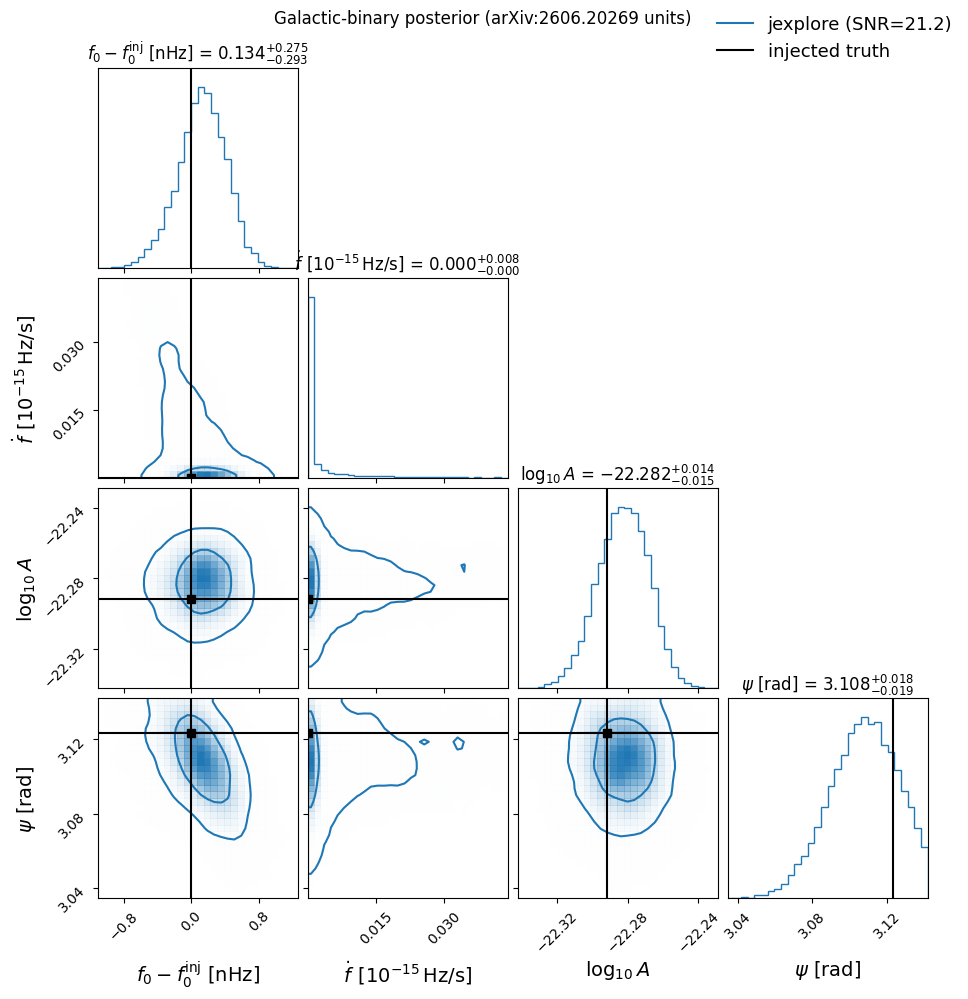

In [6]:
# Corner plot in the display units of arXiv:2606.20269:
#   f0   -> (f0 - f0_inj) in nHz  (panel centred at 0)
#   fdot -> units of 1e-15 Hz/s   (linear, not log)
#   A    -> log10 A
#   psi  -> rad
# chain columns are θ = [ln f0, ln fdot, ln A, psi] (natural logs from theta_true).

F0_TRUE   = params[idx, 0, 0]
FDOT_TRUE = params[idx, 0, 1]
A_TRUE    = params[idx, 0, 2]
PSI_TRUE  = params[idx, 0, 5]   # BUGFIX: psi is index 5 (index 6 is iota)

to_plot = lambda a: np.column_stack([
    (np.exp(a[:, 0]) - F0_TRUE) * 1e9,   # f0 - f0_inj  [nHz]
    np.exp(a[:, 1]) * 1e15,              # fdot         [1e-15 Hz/s]
    np.log10(np.exp(a[:, 2])),           # log10 A
    a[:, 3],                             # psi          [rad]
])

plot_samples = to_plot(chain)
# f0 panel is an offset centred on the injection, so the truth marker sits at 0.
plot_truth   = [0.0, FDOT_TRUE * 1e15, np.log10(A_TRUE), float(PSI_TRUE)]
plot_labels  = [r"$f_0 - f_0^{\mathrm{inj}}$ [nHz]",
                r"$\dot f\ [10^{-15}\,\mathrm{Hz/s}]$",
                r"$\log_{10} A$",
                r"$\psi$ [rad]"]

plt.close("all")
fig = corner.corner(
    plot_samples,
    labels=plot_labels,
    truths=plot_truth,
    truth_color="black",
    color="C0",
    plot_datapoints=False,
    smooth=1.0,
    bins=30,
    levels=(0.5, 0.9),
    max_n_ticks=3,
    show_titles=True,
    title_fmt=".3f",
    hist_kwargs={"density": True},
    label_kwargs={"fontsize": 14},
)
fig.legend(
    handles=[
        mlines.Line2D([], [], color="C0", label=f"jexplore (SNR={snr[idx]:.1f})"),
        mlines.Line2D([], [], color="black", label="injected truth"),
    ],
    loc="upper right", fontsize=13, frameon=False,
)
fig.suptitle("Galactic-binary posterior (arXiv:2606.20269 units)", y=1.02)
#fig.savefig("GB_inference_corner.pdf", bbox_inches="tight")
plt.show()
#print("saved GB_inference_corner.pdf")